# 12 · Hyperparameter Tuning — Sprint 4
**Proyecto:** Detección de Sitios Web Fraudulentos (Phishing)  
**Sprint 4 — PB-13:** Optimización de hiperparámetros de los candidatos del Sprint 3

---

## Objetivo

Optimizar los hiperparámetros de los **top candidatos seleccionados en el Sprint 3** usando:
- `GridSearchCV` para espacios pequeños (bien acotados)
- `RandomizedSearchCV` para espacios grandes
- Comparar métricas **antes vs. después** del tuning
- Persistir los modelos tuneados con `joblib`

## Candidatos del Sprint 3 (justificación)

| Modelo | Justificación para tuning |
|--------|---------------------------|
| Random Forest | Mejor F1 y AUC-ROC baseline, overfitting controlado |
| Gradient Boosting | Segundo mejor F1, alto potencial de mejora con tuning |
| Logistic Regression | Modelo interpretable, candidato de referencia |

> **Regla de oro Sprint 4:** El test set **no** se toca en esta notebook. Todo el tuning se hace sobre train con CV estratificado.

## 1. Imports y configuración

In [21]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from src.models import build_full_pipeline, load_model
from src.tuning import tune_model, tune_model_random, log_experiment, compare_metrics

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('✓ Librerías cargadas.')

✓ Librerías cargadas.


## 2. Cargar datos de entrenamiento y pipeline de preprocesamiento

In [24]:
TARGET_COL = 'Result'

# Cargar datos crudos de entrenamiento (con SMOTE aplicado, sin escalar)
train_df = pd.read_csv('./data/processed/train.csv')
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

# Cargar pipeline de preprocesamiento del Sprint 2
preprocessor = joblib.load('./models/preprocessor.pkl')

print(f'X_train shape: {X_train.shape}')
print(f'y_train distribución: {dict(y_train.value_counts().sort_index())}')
print(f'Features ({len(X_train.columns)}): {X_train.columns.tolist()}')

X_train shape: (4830, 37)
y_train distribución: {-1: np.int64(2415), 1: np.int64(2415)}
Features (37): ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'url_risk_score', 'security_score', 'total_suspicious_count', 'total_legitimate_count', 'net_signal_ratio', 'ssl_traffic_interaction', 'content_risk_score']


## 3. CV estratificado global

Se define un único `StratifiedKFold` con 5 folds para todos los experimentos de esta notebook. Esto garantiza comparabilidad entre todos los modelos tuneados.

In [25]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'f1'  # Métrica principal definida en Sprint 1

print(f'CV estratificado: {CV.n_splits} folds, shuffle=True, random_state={RANDOM_STATE}')
print(f'Métrica de scoring: {SCORING}')

CV estratificado: 5 folds, shuffle=True, random_state=42
Métrica de scoring: f1


## 4. Cargar baselines del Sprint 3

Se cargan los pipelines completos (preproc + clf) persistidos en el Sprint 3 para tener la referencia de rendimiento baseline.

In [27]:
# Cargar baselines del Sprint 3
baseline_rf = load_model('random_forest', model_dir='./models')
baseline_gb = load_model('gradient_boosting', model_dir='./models')
baseline_lr = load_model('logistic_regression', model_dir='./models')

# Calcular F1 baseline con CV para referencia
def get_baseline_f1(model, X, y, cv, name):
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    print(f'  {name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')
    return scores.mean()

print('\n📊 F1-Score baseline (Sprint 3, CV 5-fold):')
f1_baseline_rf = get_baseline_f1(baseline_rf, X_train, y_train, CV, 'Random Forest')
f1_baseline_gb = get_baseline_f1(baseline_gb, X_train, y_train, CV, 'Gradient Boosting')
f1_baseline_lr = get_baseline_f1(baseline_lr, X_train, y_train, CV, 'Logistic Regression')

[load_model] 'random_forest' cargado desde './models\baseline_random_forest.pkl'.
[load_model] 'gradient_boosting' cargado desde './models\baseline_gradient_boosting.pkl'.
[load_model] 'logistic_regression' cargado desde './models\baseline_logistic_regression.pkl'.

📊 F1-Score baseline (Sprint 3, CV 5-fold):
  Random Forest: F1 = 0.9419 ± 0.0076
  Gradient Boosting: F1 = 0.9417 ± 0.0042
  Logistic Regression: F1 = 0.9350 ± 0.0058


## 5. Tuning — Random Forest

### 5.1 Definición del espacio de búsqueda

Se usa `RandomizedSearchCV` (espacio grande) como primera pasada para acotar la región prometedora, seguida de `GridSearchCV` fino en esa región.

**Hiperparámetros clave de Random Forest:**
- `n_estimators`: número de árboles (más = mejor pero más lento)
- `max_depth`: profundidad máxima del árbol (controla overfitting)
- `min_samples_split` / `min_samples_leaf`: regularización de nodos
- `max_features`: fracción de features por árbol (diversidad)

In [28]:
# Pipeline RF para tuning: usar datos crudos (el preproc está dentro del pipeline)
pipe_rf = build_full_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
)

# ── PASO 1: RandomizedSearchCV (exploración amplia) ──
param_dist_rf = {
    'clf__n_estimators':      randint(100, 600),
    'clf__max_depth':         [5, 10, 15, 20, 30, None],
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf':  randint(1, 10),
    'clf__max_features':      ['sqrt', 'log2', 0.5, 0.7],
    'clf__class_weight':      [None, 'balanced'],
}

print('🔍 RandomizedSearchCV — Random Forest (n_iter=80)...')
result_rf_random = tune_model_random(
    pipe_rf, param_dist_rf, X_train, y_train,
    n_iter=80, cv=CV, scoring=SCORING, name='random_forest'
)

print(f"\n Mejor F1 (RandomizedSearch): {result_rf_random['best_score']:.4f}")
print(f"   Mejores parámetros: {result_rf_random['best_params']}")
print(f"   Tiempo: {result_rf_random['time_seconds']}s")

🔍 RandomizedSearchCV — Random Forest (n_iter=80)...

✅ Mejor F1 (RandomizedSearch): 0.9436
   Mejores parámetros: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 317}
   Tiempo: 78.3s


In [29]:
# ── PASO 2: GridSearchCV (refinamiento fino) ──
# Se usa la región prometedora encontrada por RandomizedSearch
best_rf_params = result_rf_random['best_params']

# Grid fino alrededor del mejor resultado
n_est_best = best_rf_params.get('clf__n_estimators', 200)
depth_best = best_rf_params.get('clf__max_depth', 15)

param_grid_rf = {
    'clf__n_estimators':      [max(50, n_est_best - 50), n_est_best, n_est_best + 50],
    'clf__max_depth':         [depth_best] if depth_best is None else [max(3, depth_best - 5), depth_best, depth_best + 5],
    'clf__min_samples_split': [best_rf_params.get('clf__min_samples_split', 2)],
    'clf__min_samples_leaf':  [best_rf_params.get('clf__min_samples_leaf', 1)],
    'clf__max_features':      [best_rf_params.get('clf__max_features', 'sqrt')],
    'clf__class_weight':      [best_rf_params.get('clf__class_weight', None)],
}

print('🔍 GridSearchCV fino — Random Forest...')
result_rf_grid = tune_model(
    pipe_rf, param_grid_rf, X_train, y_train,
    cv=CV, scoring=SCORING, name='random_forest'
)

print(f"\n✅ Mejor F1 (GridSearch): {result_rf_grid['best_score']:.4f}")
print(f"   Mejores parámetros: {result_rf_grid['best_params']}")
print(f"   ΔF1 vs baseline: +{result_rf_grid['best_score'] - f1_baseline_rf:.4f}")

🔍 GridSearchCV fino — Random Forest...

✅ Mejor F1 (GridSearch): 0.9442
   Mejores parámetros: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 267}
   ΔF1 vs baseline: +0.0023


In [31]:
# Registrar experimento
log_experiment(result_rf_grid, log_path='./models/experiments_log.csv')

# Cargar el modelo tuneado (ya fue persistido por tune_model)
tuned_rf = joblib.load(result_rf_grid['path'])
print(f'\n✅ Modelo RF tuneado cargado desde: {result_rf_grid["path"]}')

[log] Experimento 'random_forest' registrado en ./models/experiments_log.csv

✅ Modelo RF tuneado cargado desde: models/tuned_random_forest.pkl


## 6. Tuning — Gradient Boosting

**Hiperparámetros clave de Gradient Boosting:**
- `n_estimators`: número de etapas de boosting
- `learning_rate`: tasa de aprendizaje (trade-off con n_estimators)
- `max_depth`: profundidad de cada árbol base (3–5 suele ser óptimo)
- `subsample`: fracción de muestras por árbol (reduce overfitting)
- `min_samples_leaf`: regularización adicional

In [32]:
pipe_gb = build_full_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=RANDOM_STATE)
)

# RandomizedSearchCV — exploración
param_dist_gb = {
    'clf__n_estimators':   randint(100, 500),
    'clf__learning_rate':  uniform(0.01, 0.29),      # [0.01, 0.30]
    'clf__max_depth':      [3, 4, 5, 6, 7],
    'clf__subsample':      uniform(0.6, 0.4),         # [0.6, 1.0]
    'clf__min_samples_leaf': randint(1, 15),
    'clf__max_features':   ['sqrt', 'log2', None],
}

print('🔍 RandomizedSearchCV — Gradient Boosting (n_iter=60)...')
result_gb_random = tune_model_random(
    pipe_gb, param_dist_gb, X_train, y_train,
    n_iter=60, cv=CV, scoring=SCORING, name='gradient_boosting'
)

print(f"\n✅ Mejor F1 (RandomizedSearch): {result_gb_random['best_score']:.4f}")
print(f"   Mejores parámetros: {result_gb_random['best_params']}")
print(f"   ΔF1 vs baseline: +{result_gb_random['best_score'] - f1_baseline_gb:.4f}")

🔍 RandomizedSearchCV — Gradient Boosting (n_iter=60)...

✅ Mejor F1 (RandomizedSearch): 0.9509
   Mejores parámetros: {'clf__learning_rate': np.float64(0.04059333535077848), 'clf__max_depth': 6, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 14, 'clf__n_estimators': 430, 'clf__subsample': np.float64(0.7297380084021096)}
   ΔF1 vs baseline: +0.0092


In [34]:
# GridSearchCV fino — Gradient Boosting
best_gb_params = result_gb_random['best_params']
lr_best = round(best_gb_params.get('clf__learning_rate', 0.1), 3)

param_grid_gb = {
    'clf__n_estimators':    [best_gb_params.get('clf__n_estimators', 200)],
    'clf__learning_rate':   [max(0.01, lr_best - 0.03), lr_best, lr_best + 0.03],
    'clf__max_depth':       [best_gb_params.get('clf__max_depth', 4)],
    'clf__subsample':       [round(best_gb_params.get('clf__subsample', 0.8), 2)],
    'clf__min_samples_leaf':[best_gb_params.get('clf__min_samples_leaf', 1)],
    'clf__max_features':    [best_gb_params.get('clf__max_features', 'sqrt')],
}

print('🔍 GridSearchCV fino — Gradient Boosting...')
result_gb_grid = tune_model(
    pipe_gb, param_grid_gb, X_train, y_train,
    cv=CV, scoring=SCORING, name='gradient_boosting'
)

print(f"\n✅ Mejor F1 (GridSearch): {result_gb_grid['best_score']:.4f}")
print(f"   Mejores parámetros: {result_gb_grid['best_params']}")
print(f"   ΔF1 vs baseline: +{result_gb_grid['best_score'] - f1_baseline_gb:.4f}")

log_experiment(result_gb_grid, log_path='./models/experiments_log.csv')
tuned_gb = joblib.load(result_gb_grid['path'])

🔍 GridSearchCV fino — Gradient Boosting...

✅ Mejor F1 (GridSearch): 0.9468
   Mejores parámetros: {'clf__learning_rate': np.float64(0.041), 'clf__max_depth': 6, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 14, 'clf__n_estimators': 430, 'clf__subsample': np.float64(0.73)}
   ΔF1 vs baseline: +0.0051
[log] Experimento 'gradient_boosting' registrado en ./models/experiments_log.csv


## 7. Tuning — Logistic Regression

**Hiperparámetros clave de Logistic Regression:**
- `C`: inverso de la regularización (C pequeño = más regularización)
- `penalty`: tipo de regularización (`l1`, `l2`, `elasticnet`)
- `solver`: algoritmo de optimización (compatible con penalty)

Se usa `GridSearchCV` directamente por el espacio pequeño.

In [35]:
pipe_lr = build_full_pipeline(
    preprocessor,
    LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
)

param_grid_lr = {
    'clf__C':           [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__penalty':     ['l2'],          # l2 compatible con lbfgs y saga
    'clf__solver':      ['lbfgs', 'saga'],
    'clf__class_weight':[None, 'balanced'],
}

print('🔍 GridSearchCV — Logistic Regression...')
result_lr_grid = tune_model(
    pipe_lr, param_grid_lr, X_train, y_train,
    cv=CV, scoring=SCORING, name='logistic_regression'
)

print(f"\n✅ Mejor F1 (GridSearch): {result_lr_grid['best_score']:.4f}")
print(f"   Mejores parámetros: {result_lr_grid['best_params']}")
print(f"   ΔF1 vs baseline: +{result_lr_grid['best_score'] - f1_baseline_lr:.4f}")

log_experiment(result_lr_grid, log_path='./models/experiments_log.csv')
tuned_lr = joblib.load(result_lr_grid['path'])

🔍 GridSearchCV — Logistic Regression...

✅ Mejor F1 (GridSearch): 0.9374
   Mejores parámetros: {'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
   ΔF1 vs baseline: +0.0024
[log] Experimento 'logistic_regression' registrado en ./models/experiments_log.csv


## 8. Tabla comparativa — Baseline vs. Tuned

In [36]:
from sklearn.model_selection import cross_validate as cv_multi

SCORING_MULTI = {'f1': 'f1', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'}

def cv_metrics(model, X, y, cv):
    res = cv_multi(model, X, y, cv=cv, scoring=SCORING_MULTI, n_jobs=-1)
    return {
        'F1':        round(res['test_f1'].mean(), 4),
        'AUC-ROC':   round(res['test_roc_auc'].mean(), 4),
        'Recall':    round(res['test_recall'].mean(), 4),
        'Precision': round(res['test_precision'].mean(), 4),
    }

models_comparison = {
    'RF Baseline':  baseline_rf,
    'RF Tuned':     tuned_rf,
    'GB Baseline':  baseline_gb,
    'GB Tuned':     tuned_gb,
    'LR Baseline':  baseline_lr,
    'LR Tuned':     tuned_lr,
}

rows = []
for label, model in models_comparison.items():
    m = cv_metrics(model, X_train, y_train, CV)
    m['Modelo'] = label
    rows.append(m)

df_comparison = pd.DataFrame(rows)[['Modelo', 'F1', 'AUC-ROC', 'Recall', 'Precision']]

# Calcular mejora
for clf in ['RF', 'GB', 'LR']:
    baseline_row = df_comparison[df_comparison['Modelo'] == f'{clf} Baseline'].iloc[0]
    tuned_row    = df_comparison[df_comparison['Modelo'] == f'{clf} Tuned'].iloc[0]
    delta = tuned_row['F1'] - baseline_row['F1']
    pct   = (delta / baseline_row['F1'] * 100)
    print(f'{clf}: ΔF1 = {delta:+.4f} ({pct:+.1f}%)')

print()
df_comparison

RF: ΔF1 = +0.0023 (+0.2%)
GB: ΔF1 = +0.0051 (+0.5%)
LR: ΔF1 = +0.0024 (+0.3%)



,Modelo,F1,AUC-ROC,Recall,Precision
0,RF Baseline,0.9419,0.9861,0.9507,0.9334
1,RF Tuned,0.9442,0.9879,0.9532,0.9355
2,GB Baseline,0.9417,0.9881,0.9503,0.9334
3,GB Tuned,0.9468,0.9917,0.9536,0.9401
4,LR Baseline,0.9350,0.9839,0.9449,0.9255
5,LR Tuned,0.9374,0.9847,0.9453,0.9296


## 9. Visualización — Mejora post-tuning

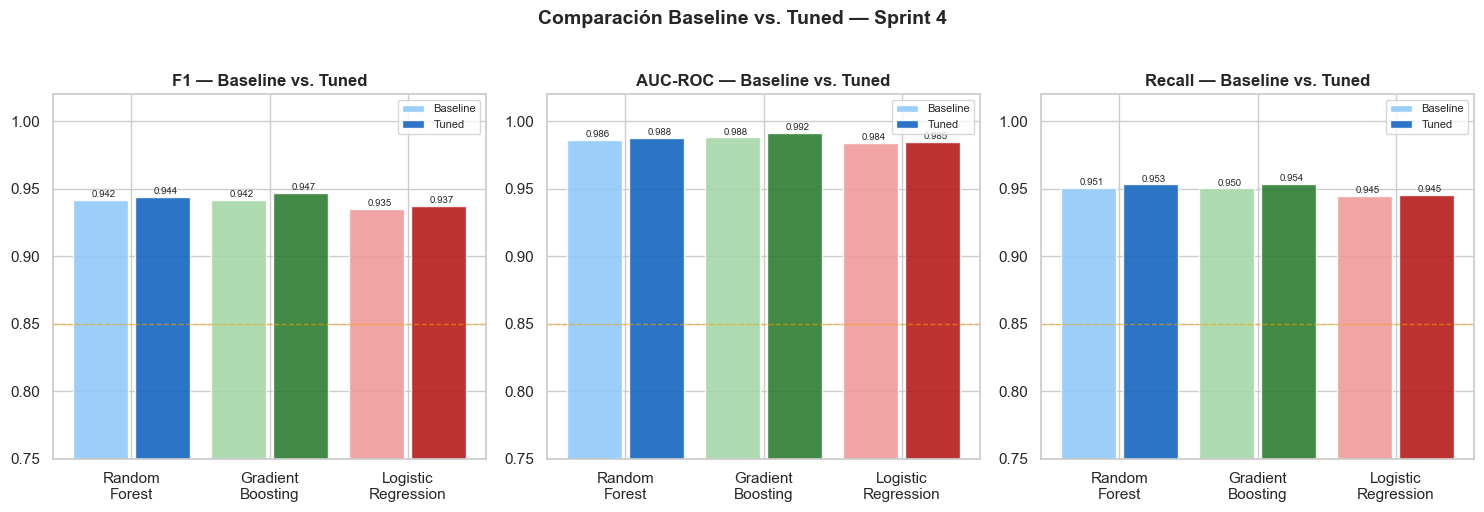

✅ Gráfico guardado en reports/figures/tuning_comparison.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['F1', 'AUC-ROC', 'Recall']
colors_baseline = ['#90caf9', '#a5d6a7', '#ef9a9a']
colors_tuned    = ['#1565c0', '#2e7d32', '#b71c1c']

for ax, metric in zip(axes, metrics_to_plot):
    for i, (clf, cb, ct) in enumerate(zip(['RF', 'GB', 'LR'], colors_baseline, colors_tuned)):
        val_base  = df_comparison[df_comparison['Modelo'] == f'{clf} Baseline'][metric].values[0]
        val_tuned = df_comparison[df_comparison['Modelo'] == f'{clf} Tuned'][metric].values[0]
        x = i * 2
        ax.bar(x,     val_base,  0.8, color=cb, label='Baseline' if i == 0 else '', alpha=0.9)
        ax.bar(x + 0.9, val_tuned, 0.8, color=ct, label='Tuned'    if i == 0 else '', alpha=0.9)
        ax.text(x + 0.05, val_base  + 0.002, f'{val_base:.3f}',  fontsize=7, ha='center')
        ax.text(x + 0.95, val_tuned + 0.002, f'{val_tuned:.3f}', fontsize=7, ha='center')

    ax.set_xticks([0.45, 2.45, 4.45])
    ax.set_xticklabels(['Random\nForest', 'Gradient\nBoosting', 'Logistic\nRegression'])
    ax.set_title(f'{metric} — Baseline vs. Tuned', fontweight='bold')
    ax.set_ylim(0.75, 1.02)
    ax.legend(fontsize=8)
    ax.axhline(0.85, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Umbral mínimo')

plt.suptitle('Comparación Baseline vs. Tuned — Sprint 4', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./reports/figures/tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en reports/figures/tuning_comparison.png')

## 10. Resumen del tuning y candidatos para Sprint 4 (ensambles)

Se identifican los modelos tuneados que pasarán al notebook de ensambles (`13_ensembles.ipynb`).

In [41]:
print('=' * 60)
print('  RESUMEN DE TUNING — Sprint 4, PB-13')
print('=' * 60)

best_tuned = df_comparison[df_comparison['Modelo'].str.contains('Tuned')].copy()
best_tuned = best_tuned.sort_values('F1', ascending=False).reset_index(drop=True)
best_tuned.index += 1

print(best_tuned.to_string())

print('\n📌 Candidatos para ensambles (13_ensembles.ipynb):')
for _, row in best_tuned.iterrows():
    print(f'  ✓ {row["Modelo"]} — F1={row["F1"]:.4f}, AUC={row["AUC-ROC"]:.4f}')

print('\n⚠️  RECORDATORIO: El test set NO se ha usado en ningún momento de esta notebook.')
print('   Se reserva para la validación final en 14_final_validation.ipynb')

  RESUMEN DE TUNING — Sprint 4, PB-13
     Modelo      F1  AUC-ROC  Recall  Precision
1  GB Tuned  0.9468   0.9917  0.9536     0.9401
2  RF Tuned  0.9442   0.9879  0.9532     0.9355
3  LR Tuned  0.9374   0.9847  0.9453     0.9296

📌 Candidatos para ensambles (13_ensembles.ipynb):
  ✓ GB Tuned — F1=0.9468, AUC=0.9917
  ✓ RF Tuned — F1=0.9442, AUC=0.9879
  ✓ LR Tuned — F1=0.9374, AUC=0.9847

⚠️  RECORDATORIO: El test set NO se ha usado en ningún momento de esta notebook.
   Se reserva para la validación final en 14_final_validation.ipynb
